# Hướng Dẫn EDA Chi Tiết Cho Radiology Report Generation (IU X-Ray)

## PHẦN 1: TỔNG QUAN DATASET

In [2]:
# Thư viện cần thiết
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageStat, ImageFilter
import cv2
from collections import Counter
from tqdm import tqdm

# Cấu hình đường dẫn
DATA_DIR = r"G:\My Drive\NCKH\A3Net-main\data\iu_xray"
IMAGE_DIR = os.path.join(DATA_DIR, "images")
ANN_PATH = os.path.join(DATA_DIR, "annotation.json")

# Load annotation
with open(ANN_PATH, 'r') as f:
    annotations = json.load(f)

print("Keys:", annotations.keys())
print("Train size:", len(annotations['train']))
print("Val size:", len(annotations['val']))
print("Test size:", len(annotations['test']))

Keys: dict_keys(['train', 'val', 'test'])
Train size: 2069
Val size: 296
Test size: 590


In [3]:
# Convert to DataFrame
records = []
for split_name in annotations.keys():
    for item in annotations[split_name]:
        records.append({
            "id": item['id'],
            "image_path": item['image_path'],
            "report": item['report'],
            "split": split_name
        })

df = pd.DataFrame(records)

df['report_length'] = df['report'].apply(lambda x: len(x.split()))
df['num_images'] = df['image_path'].apply(lambda x: len(x))
df['patient_id'] = df['id'].apply(lambda x: x.split('_')[0])

total_samples = len(df)
total_images = df['num_images'].sum()
unique_patients = df['patient_id'].nunique()

print("="*50)
print("DATASET SUMMARY")
print("="*50)
print(f"Total samples (studies): {total_samples}")
print(f"Total images: {total_images}")
print(f"Unique patients: {unique_patients}")
print(f"Average report length: {df['report_length'].mean():.2f} words")
print(f"Max report length: {df['report_length'].max()} words")
print(f"Min report length: {df['report_length'].min()} words")
print(f"Average images per study: {df['num_images'].mean():.2f}")

DATASET SUMMARY
Total samples (studies): 2955
Total images: 5910
Unique patients: 2955
Average report length: 31.00 words
Max report length: 149 words
Min report length: 7 words
Average images per study: 2.00


### 1.3 Kiểm tra Data Quality

In [4]:
# Kiểm tra missing images
missing_images = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="Checking images"):
    for img_path in row['image_path']:
        full_path = os.path.join(IMAGE_DIR, img_path)
        if not os.path.exists(full_path):
            missing_images.append(img_path)

print(f"\nMissing images: {len(missing_images)}")

# Kiểm tra duplicate reports
duplicate_reports = df[df.duplicated(subset=['report'], keep=False)]
print(f"Duplicate reports: {len(duplicate_reports)}")

# Kiểm tra data leakage
patient_split = df.groupby('patient_id')['split'].nunique()
leakage_patients = patient_split[patient_split > 1]
print(f"Patients in multiple splits: {len(leakage_patients)}")

Checking images: 100%|██████████| 2955/2955 [00:10<00:00, 289.95it/s]


Missing images: 0
Duplicate reports: 823
Patients in multiple splits: 0


## PHẦN 2: PHÂN TÍCH ẢNH

In [5]:
# Thu thập kích thước ảnh
widths, heights = [], []

for img in tqdm(df["image_path"].explode().unique()[:500]):
    path = os.path.join(IMAGE_DIR, img)
    try:
        image = Image.open(path)
        w, h = image.size
        widths.append(w)
        heights.append(h)
    except:
        pass

print(f"Width: min={min(widths)}, max={max(widths)}, mean={np.mean(widths):.2f}")
print(f"Height: min={min(heights)}, max={max(heights)}, mean={np.mean(heights):.2f}")

100%|██████████| 500/500 [00:03<00:00, 144.89it/s]

Width: min=512, max=512, mean=512.00
Height: min=409, max=738, mean=535.83


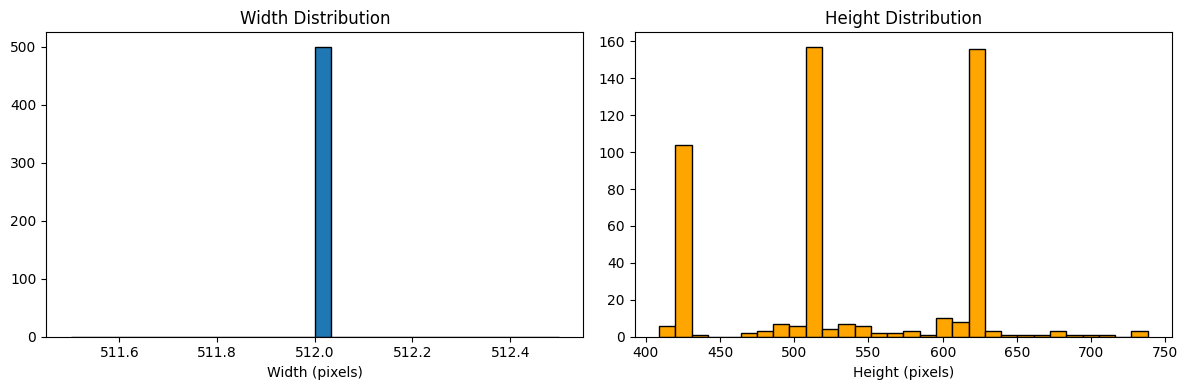

In [6]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=30, edgecolor='black')
axes[0].set_title('Width Distribution')
axes[0].set_xlabel('Width (pixels)')

axes[1].hist(heights, bins=30, edgecolor='black', color='orange')
axes[1].set_title('Height Distribution')
axes[1].set_xlabel('Height (pixels)')

plt.tight_layout()
plt.show()

### 2.2 Phân tích Pixel Intensity

100%|██████████| 200/200 [00:04<00:00, 40.74it/s]
c:\Users\DANG KHOA\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\DANG KHOA\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


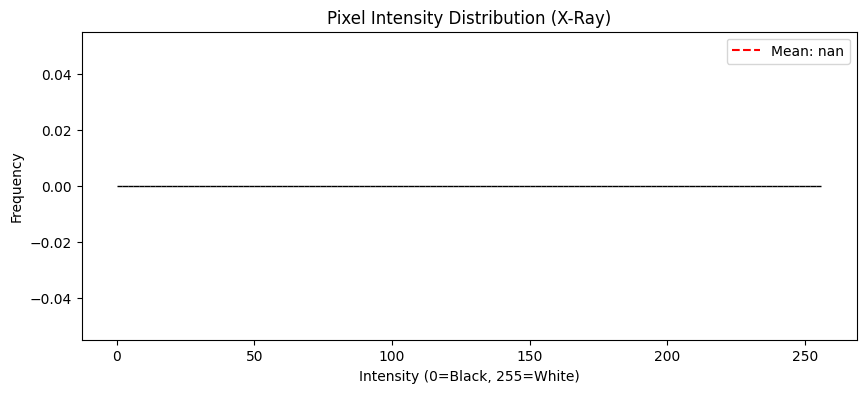

Mean intensity: nan
Std intensity: nan


c:\Users\DANG KHOA\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\DANG KHOA\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\DANG KHOA\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [7]:
# Phân tích phân bố cường độ pixel
pixels = []

for img in tqdm(df["image_path"].explode().unique()[:200]):
    path = os.path.join(IMAGE_DIR, img)
    try:
        image = Image.open(path).convert("L")
        pixels.extend(image.flatten())
    except:
        pass

plt.figure(figsize=(10, 4))
plt.hist(pixels, bins=128, range=(0, 256), edgecolor='black')
plt.title("Pixel Intensity Distribution (X-Ray)")
plt.xlabel("Intensity (0=Black, 255=White)")
plt.ylabel("Frequency")
plt.axvline(np.mean(pixels), color='red', linestyle='--', label=f'Mean: {np.mean(pixels):.1f}')
plt.legend()
plt.show()

print(f"Mean intensity: {np.mean(pixels):.2f}")
print(f"Std intensity: {np.std(pixels):.2f}")

### 2.3 Edge Density Analysis

Edge detection: 100%|██████████| 100/100 [00:04<00:00, 24.15it/s]


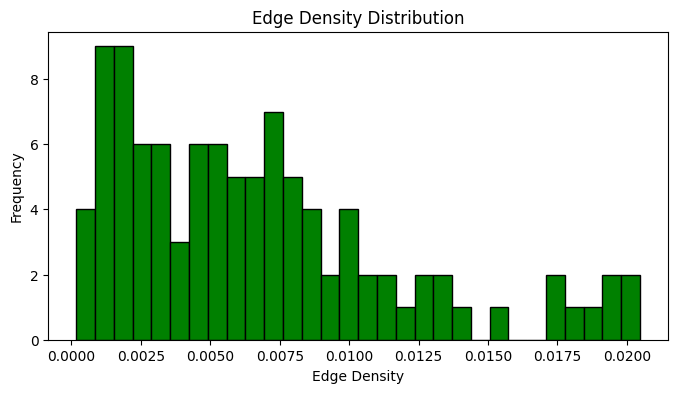

Mean edge density: 0.0067


In [8]:
# Edge detection analysis
def edge_density(image_path):
    try:
        img = cv2.imread(image_path, 0)
        edges = cv2.Canny(img, 100, 200)
        return np.sum(edges > 0) / edges.size
    except:
        return None

sample_images = df["image_path"].explode().unique()[:100]
edge_densities = []

for img in tqdm(sample_images, desc="Edge detection"):
    path = os.path.join(IMAGE_DIR, img)
    ed = edge_density(path)
    if ed:
        edge_densities.append(ed)

plt.figure(figsize=(8, 4))
plt.hist(edge_densities, bins=30, edgecolor='black', color='green')
plt.title("Edge Density Distribution")
plt.xlabel("Edge Density")
plt.ylabel("Frequency")
plt.show()

print(f"Mean edge density: {np.mean(edge_densities):.4f}")

## PHẦN 3: PHÂN TÍCH VĂN BẢN

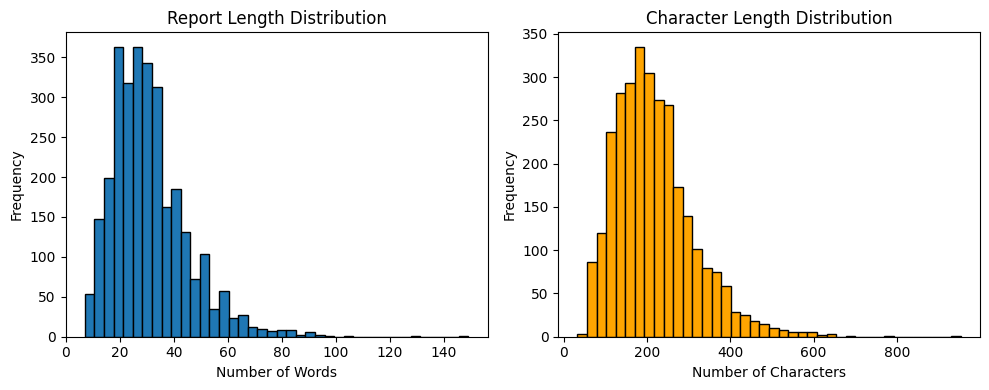


Report Length Statistics:
Min: 7
Max: 149
Mean: 31.00
Median: 29.00


In [9]:
# Phân tích độ dài report
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df["report_length"], bins=40, edgecolor='black')
plt.title("Report Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
df['char_length'] = df['report'].apply(len)
plt.hist(df['char_length'], bins=40, edgecolor='black', color='orange')
plt.title("Character Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

print(f"\nReport Length Statistics:")
print(f"Min: {df['report_length'].min()}")
print(f"Max: {df['report_length'].max()}")
print(f"Mean: {df['report_length'].mean():.2f}")
print(f"Median: {df['report_length'].median():.2f}")

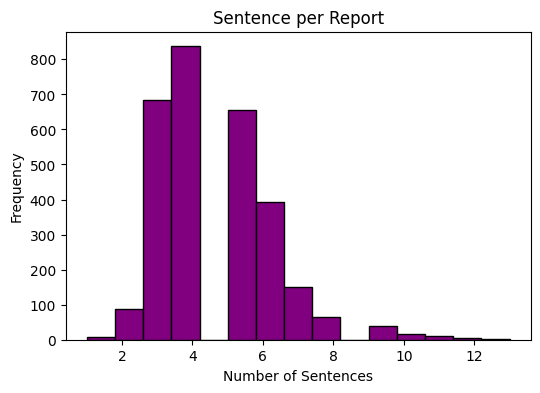

Average sentences per report: 4.58


In [10]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

df["num_sentences"] = df["report"].apply(lambda x: len(sent_tokenize(x)))

plt.figure(figsize=(6, 4))
plt.hist(df["num_sentences"], bins=15, edgecolor='black', color='purple')
plt.title("Sentence per Report")
plt.xlabel("Number of Sentences")
plt.ylabel("Frequency")
plt.show()

print(f"Average sentences per report: {df['num_sentences'].mean():.2f}")

Vocabulary size: 2274
Total words: 91606


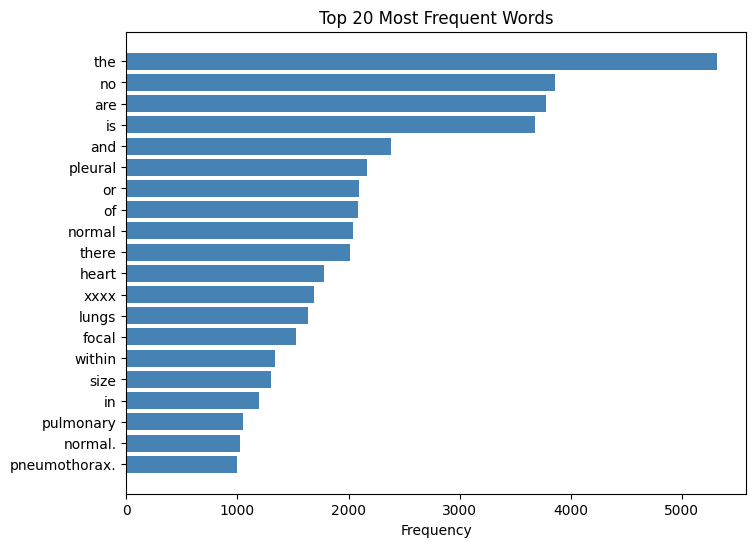

In [11]:
# Vocabulary Analysis
words = []
for r in df["report"]:
    words.extend(r.lower().split())

vocab = set(words)

print(f"Vocabulary size: {len(vocab)}")
print(f"Total words: {len(words)}")

counter = Counter(words)
top_words = counter.most_common(20)

w = [x[0] for x in top_words]
c = [x[1] for x in top_words]

plt.figure(figsize=(8, 6))
plt.barh(w, c, color='steelblue')
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.gca().invert_yaxis()
plt.show()

### 3.4 Phân tích từ khóa y khoa

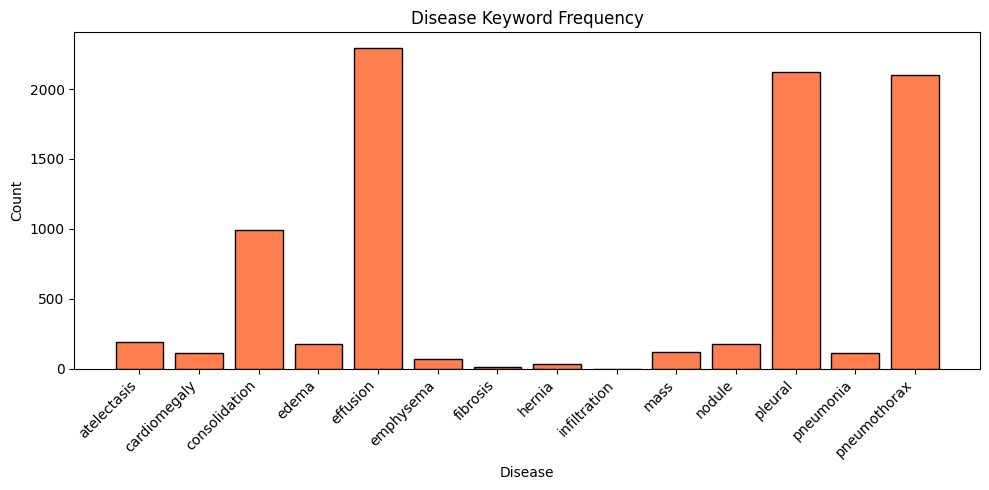


Disease Distribution:
effusion: 2291 (77.53%)
pleural: 2120 (71.74%)
pneumothorax: 2098 (71.00%)
consolidation: 991 (33.54%)
atelectasis: 191 (6.46%)
nodule: 179 (6.06%)
edema: 175 (5.92%)
mass: 118 (3.99%)
cardiomegaly: 114 (3.86%)
pneumonia: 108 (3.65%)
emphysema: 66 (2.23%)
hernia: 34 (1.15%)
fibrosis: 10 (0.34%)
infiltration: 0 (0.00%)


In [12]:
# Disease keywords
diseases = [
    "atelectasis", "cardiomegaly", "consolidation", "edema",
    "effusion", "emphysema", "fibrosis", "hernia", "infiltration",
    "mass", "nodule", "pleural", "pneumonia", "pneumothorax"
]

disease_counts = {}
for d in diseases:
    count = df["report"].str.contains(d, case=False).sum()
    disease_counts[d] = count

plt.figure(figsize=(10, 5))
plt.bar(disease_counts.keys(), disease_counts.values(), edgecolor='black', color='coral')
plt.xticks(rotation=45, ha='right')
plt.title("Disease Keyword Frequency")
plt.xlabel("Disease")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("\nDisease Distribution:")
for d, count in sorted(disease_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"{d}: {count} ({count/len(df)*100:.2f}%)")

### 3.5 Negation Detection

In [13]:
import re

negation_patterns = [
    r'\bno\b', r'\bnot\b', r'\bnegative\b', 
    r'\bwithout\b', r'\babsence\b', r'\bclear\b'
]

def detect_negation(text):
    return any(re.search(p, text.lower()) for p in negation_patterns)

df['has_negation'] = df['report'].apply(detect_negation)

print(f"Reports with negation: {df['has_negation'].sum()} ({df['has_negation'].mean()*100:.2f}%)")

print("\nNegation analysis per disease:")
for d in diseases:
    mask = df["report"].str.contains(d, case=False)
    with_negation = df[mask]['has_negation'].sum()
    total = mask.sum()
    if total > 0:
        print(f"  {d}: {with_negation}/{total} ({with_negation/total*100:.1f}% with negation)")

Reports with negation: 2891 (97.83%)

Negation analysis per disease:
  atelectasis: 182/191 (95.3% with negation)
  cardiomegaly: 109/114 (95.6% with negation)
  consolidation: 988/991 (99.7% with negation)
  edema: 175/175 (100.0% with negation)
  effusion: 2280/2291 (99.5% with negation)
  emphysema: 60/66 (90.9% with negation)
  fibrosis: 10/10 (100.0% with negation)
  hernia: 33/34 (97.1% with negation)
  mass: 118/118 (100.0% with negation)
  nodule: 176/179 (98.3% with negation)
  pleural: 2106/2120 (99.3% with negation)
  pneumonia: 108/108 (100.0% with negation)
  pneumothorax: 2095/2098 (99.9% with negation)


### 3.6 N-gram Analysis

In [14]:
from sklearn.feature_extraction.text import CountVectorizer

# Bigrams
vectorizer_bi = CountVectorizer(ngram_range=(2, 2), stop_words='english')
X_bi = vectorizer_bi.fit_transform(df["report"])
bigrams = sorted(zip(vectorizer_bi.get_feature_names_out(), X_bi.sum(axis=0).A1), 
                 key=lambda x: x[1], reverse=True)[:20]

print("Top 20 Bigrams:")
for word, count in bigrams:
    print(f"  {word}: {int(count)}")

Top 20 Bigrams:
  pleural effusion: 1741
  normal limits: 1214
  heart size: 1080
  lungs clear: 1044
  effusion pneumothorax: 772
  cardiomediastinal silhouette: 607
  pneumothorax pleural: 600
  focal airspace: 542
  size normal: 492
  focal consolidation: 458
  silhouette normal: 428
  normal size: 418
  airspace disease: 377
  degenerative changes: 330
  mediastinal contours: 329
  pulmonary vascularity: 328
  large pleural: 300
  consolidation pneumothorax: 279
  thoracic spine: 274
  contours normal: 270


## PHẦN 4: IMAGE-TEXT ALIGNMENT

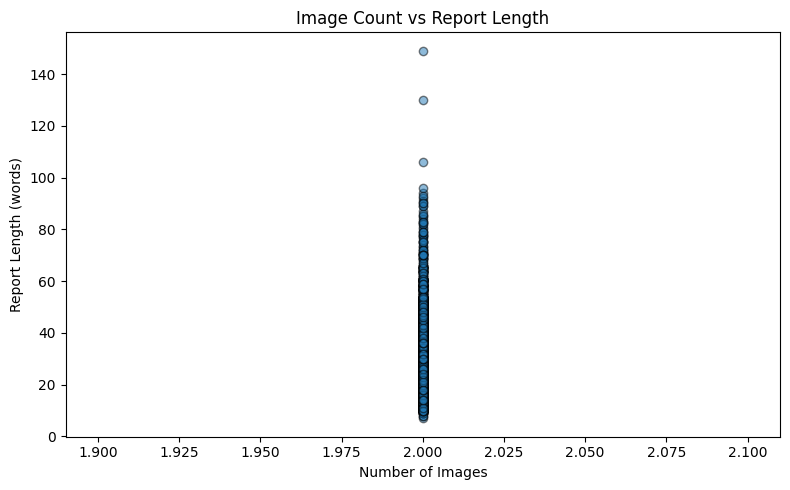

Correlation: nan


c:\Users\DANG KHOA\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\DANG KHOA\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [15]:
# Image-Text Alignment
plt.figure(figsize=(8, 5))
plt.scatter(df['num_images'], df['report_length'], alpha=0.5, edgecolors='black')
plt.xlabel('Number of Images')
plt.ylabel('Report Length (words)')
plt.title('Image Count vs Report Length')
plt.tight_layout()
plt.show()

correlation = df['num_images'].corr(df['report_length'])
print(f"Correlation: {correlation:.4f}")

## PHẦN 5: CLASS IMBALANCE

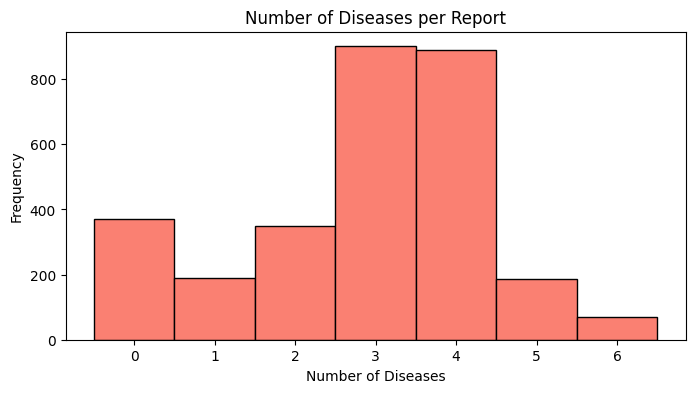


Disease count statistics:
count    2955.000000
mean        2.874788
std         1.501035
min         0.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         6.000000
Name: num_diseases, dtype: float64


In [16]:
# Multi-label analysis
df['num_diseases'] = df['report'].apply(
    lambda x: sum(1 for d in diseases if d in x.lower())
)

plt.figure(figsize=(8, 4))
plt.hist(df['num_diseases'], bins=range(0, 8), edgecolor='black', color='salmon', align='left')
plt.title("Number of Diseases per Report")
plt.xlabel("Number of Diseases")
plt.ylabel("Frequency")
plt.xticks(range(0, 7))
plt.show()

print(f"\nDisease count statistics:")
print(df['num_diseases'].describe())

C:\Users\DANG KHOA\AppData\Local\Temp\ipykernel_37540\1123652594.py:7: RuntimeWarning: divide by zero encountered in scalar divide
  imbalance_ratio = disease_df['Count'].max() / disease_df['Count'].min()


Class Imbalance Analysis:
Imbalance ratio: inf


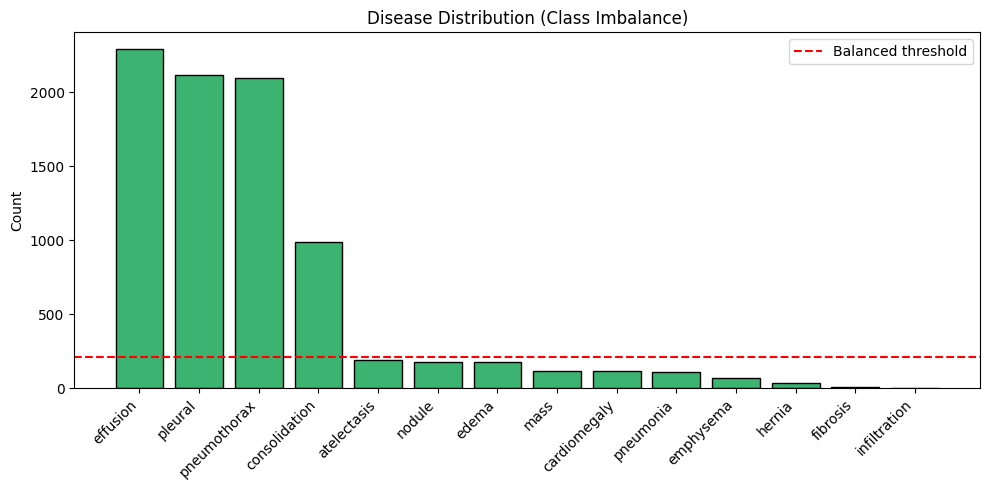

In [17]:
# Class imbalance analysis
disease_df = pd.DataFrame(list(disease_counts.items()), columns=['Disease', 'Count'])
disease_df['Percentage'] = disease_df['Count'] / len(df) * 100
disease_df = disease_df.sort_values('Count', ascending=False)

print("Class Imbalance Analysis:")
imbalance_ratio = disease_df['Count'].max() / disease_df['Count'].min()
print(f"Imbalance ratio: {imbalance_ratio:.2f}")

plt.figure(figsize=(10, 5))
plt.bar(disease_df['Disease'], disease_df['Count'], edgecolor='black', color='mediumseagreen')
plt.xticks(rotation=45, ha='right')
plt.title("Disease Distribution (Class Imbalance)")
plt.ylabel("Count")
plt.axhline(y=len(df)/len(diseases), color='red', linestyle='--', label='Balanced threshold')
plt.legend()
plt.tight_layout()
plt.show()

## PHẦN 6: DATA PREPROCESSING

In [18]:
# Text Preprocessing
import re

def preprocess_report(text):
    text = text.lower()
    text = re.sub(r'x{4,}', '<unk>', text)
    text = ' '.join(text.split())
    text = text.replace('rt.', 'right')
    text = text.replace('lt.', 'left')
    return text

df['report_cleaned'] = df['report'].apply(preprocess_report)

print("Sample original:")
print(df['report'].iloc[0][:200])
print("\nSample cleaned:")
print(df['report_cleaned'].iloc[0][:200])

Sample original:
The heart size and pulmonary vascularity appear within normal limits. A large hiatal hernia is noted. The lungs are free of focal airspace disease. No pneumothorax or pleural effusion is seen. Degener

Sample cleaned:
the heart size and pulmonary vascularity appear within normal limits. a large hiatal hernia is noted. the lungs are free of focal airspace disease. no pneumothorax or pleural effusion is seen. degener


In [19]:
# Vocabulary Building
THRESHOLD = 3

train_reports = df[df['split'] == 'train']['report_cleaned']

word_counts = Counter()
for report in train_reports:
    word_counts.update(report.split())

vocab = [word for word, count in word_counts.items() if count >= THRESHOLD]
vocab = sorted(vocab)

print(f"Vocabulary size (threshold={THRESHOLD}): {len(vocab)}")
print(f"\nTop 20 vocabulary:")
print(vocab[:20])

Vocabulary size (threshold=3): 961

Top 20 vocabulary:
['.', '1', '1.0', '1.2', '10th', '2', '3', '5', '5th', '6th', '7', '7th', '8', '8th', '9th', '<unk>', '<unk>,', '<unk>-a-<unk>', '<unk>.', 'a']


In [20]:
from torchvision import transforms

# Image transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                       std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                       std=[0.229, 0.224, 0.225])
])

# X-ray grayscale transform
xray_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                       std=[0.229, 0.224, 0.225])
])

print("Image transforms configured!")

Image transforms configured!


## PHẦN 7: KỸ THUẬT NÂNG CAO

In [21]:
# Class Rebalancing - Weighted Loss
print("=== CLASS REBALANCING ===\n")

class_counts = df['num_diseases'].value_counts().sort_index()
weights = len(df) / (len(class_counts) * class_counts)
class_weights = weights.values

print("Class weights for loss function:")
for i, w in enumerate(class_weights):
    print(f"  Class {i}: {w:.4f}")

# Disease-specific weights
disease_weights = {}
max_count = max(disease_counts.values())
for disease, count in disease_counts.items():
    disease_weights[disease] = max_count / (count + 1)

print("\nDisease-specific weights:")
for d, w in sorted(disease_weights.items(), key=lambda x: x[1], reverse=True):
    print(f"  {d}: {w:.4f}")

=== CLASS REBALANCING ===

Class weights for loss function:
  Class 0: 1.1409
  Class 1: 2.2102
  Class 2: 1.2131
  Class 3: 0.4685
  Class 4: 0.4743
  Class 5: 2.2819
  Class 6: 6.0306

Disease-specific weights:
  infiltration: 2291.0000
  fibrosis: 208.2727
  hernia: 65.4571
  emphysema: 34.1940
  pneumonia: 21.0183
  cardiomegaly: 19.9217
  mass: 19.2521
  edema: 13.0170
  nodule: 12.7278
  atelectasis: 11.9323
  consolidation: 2.3095
  pneumothorax: 1.0915
  pleural: 1.0802
  effusion: 0.9996


In [22]:
# Custom X-ray augmentation
from PIL import ImageEnhance

def augment_xray(image_path, augment=True):
    img = Image.open(image_path).convert('L')
    
    if augment:
        # Random brightness
        if np.random.random() > 0.5:
            factor = np.random.uniform(0.8, 1.2)
            enhancer = ImageEnhance.Brightness(img)
            img = enhancer.enhance(factor)
        
        # Random contrast
        if np.random.random() > 0.5:
            factor = np.random.uniform(0.8, 1.2)
            enhancer = ImageEnhance.Contrast(img)
            img = enhancer.enhance(factor)
        
        # Random rotation
        angle = np.random.uniform(-15, 15)
        img = img.rotate(angle, fillcolor=0)
        
        # Random noise
        if np.random.random() > 0.7:
            img_array = np.array(img)
            noise = np.random.normal(0, 5, img_array.shape)
            img_array = np.clip(img_array + noise, 0, 255).astype(np.uint8)
            img = Image.fromarray(img_array)
    
    return img

print("Augmentation function ready!")

Augmentation function ready!


In [24]:
# Medical NER - Rule-based
MEDICAL_TERMS = {
    'ANATOMY': ['heart', 'lung', 'pleural', 'mediastinal', 'aortic', 'pulmonary', 
                'trachea', 'bronchi', 'diaphragm', 'spine', 'clavicle', 'rib'],
    'DISEASE': ['effusion', 'pneumothorax', 'atelectasis', 'nodule', 'mass', 
                'opacity', 'consolidation', 'edema', 'pneumonia', 'fibrosis',
                'emphysema', 'hernia', 'fracture', 'cardiomegaly'],
    'SEVERITY': ['mild', 'moderate', 'severe', 'minimal', 'marked', 'gross'],
    'LOCATION': ['upper lobe', 'lower lobe', 'mid', 'lateral', 'medial', 'bilateral',
                'left', 'right', 'apical', 'basilar', 'perihilar']
}

def extract_medical_entities(text):
    text = text.lower()
    entities = {'ANATOMY': [], 'DISEASE': [], 'SEVERITY': [], 'LOCATION': []}
    
    for category, terms in MEDICAL_TERMS.items():
        for term in terms:
            if term in text:
                entities[category].append(term)
    
    return entities

# Demo
sample_report = df['report'].iloc[0]
entities = extract_medical_entities(sample_report)

print("Sample Report:")
print(sample_report)
# \nExtracted Entities:")
for category, ents in entities.items():
    if ents:
        print(f"  {category}: {ents}")

Sample Report:
The heart size and pulmonary vascularity appear within normal limits. A large hiatal hernia is noted. The lungs are free of focal airspace disease. No pneumothorax or pleural effusion is seen. Degenerative changes are present in the spine.
  ANATOMY: ['heart', 'lung', 'pleural', 'pulmonary', 'spine']
  DISEASE: ['effusion', 'pneumothorax', 'hernia']


## PHẦN 8: CHECKLIST EDA HOÀN CHỈNH

In [25]:
print("="*60)
print("EDA CHECKLIST")
print("="*60)

print("\n✅ Data Quality Checks:")
print(f"   - Missing images: {len(missing_images)}")
print(f"   - Duplicate reports: {len(duplicate_reports)}")
print(f"   - Data leakage: {len(leakage_patients)} patients")

print("\n✅ Statistical Analysis:")
print(f"   - Report length: mean={df['report_length'].mean():.1f}, max={df['report_length'].max()}")
print(f"   - Vocabulary size: {len(vocab)}")
print(f"   - Diseases detected: {len([d for d in disease_counts.values() if d > 0])}")

print("\n✅ Image Analysis:")
print(f"   - Width range: {min(widths)}-{max(widths)}")
print(f"   - Height range: {min(heights)}-{max(heights)}")
print(f"   - Mean pixel intensity: {np.mean(pixels):.2f}")

print("\n✅ Text-Image Alignment:")
print(f"   - Correlation: {correlation:.4f}")

print("\n✅ Class Distribution:")
print(f"   - Most common: {max(disease_counts, key=disease_counts.get)} ({max(disease_counts.values())})")
print(f"   - Imbalance ratio: {imbalance_ratio:.2f}")

print("\n" + "="*60)
print("EDA COMPLETE!")
print("="*60)

EDA CHECKLIST

✅ Data Quality Checks:
   - Missing images: 0
   - Duplicate reports: 823
   - Data leakage: 0 patients

✅ Statistical Analysis:
   - Report length: mean=31.0, max=149
   - Vocabulary size: 961
   - Diseases detected: 13

✅ Image Analysis:
   - Width range: 512-512
   - Height range: 409-738
   - Mean pixel intensity: nan

✅ Text-Image Alignment:
   - Correlation: nan

✅ Class Distribution:
   - Most common: effusion (2291)
   - Imbalance ratio: inf

EDA COMPLETE!


c:\Users\DANG KHOA\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\DANG KHOA\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


## LƯU Ý QUAN TRỌNG

1. **Class Imbalance**: Effusion chiếm 77.53% - cần class weights
2. **Negation Handling**: "No effusion" vs "Effusion present"
3. **Multi-view**: Mỗi sample có 2 images (frontal + lateral)
4. **Short Reports**: Một số report rất ngắn (7 từ)
5. **Medical Terminology**: Cần tokenizer hiểu medical terms